In [28]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages to keep output clean
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [29]:
# ============================================================
# Load the Seoul Bike Sharing Dataset
# ============================================================

# Load the dataset
df = pd.read_csv("SeoulBikeData.csv", encoding="latin1")

# Display first five rows
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [30]:
# ============================================================
#  Checking Dataset Shape and Column Names
# ============================================================

# Check number of rows and columns
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (8760, 14)

Column names:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


In [31]:
# ============================================================
#  Check Dataset Information
# ============================================================

# Display data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [32]:
# ============================================================
#   Summary Statistics of Numerical Columns
# ============================================================

# Show statistical summary
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [33]:
# ============================================================
#   Clean Column Names
# ============================================================

# Removing extra spaces and replace spaces/symbols with underscores
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)
df.columns = df.columns.str.replace("/", "_", regex=False)

# Displaying updated column names
print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Date', 'Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']


In [34]:
# ============================================================
#  Check Missing Values
# ============================================================

# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Date                       0
Rented_Bike_Count          0
Hour                       0
Temperature°C              0
Humidity%                  0
Wind_speed_m_s             0
Visibility_10m             0
Dew_point_temperature°C    0
Solar_Radiation_MJ_m2      0
Rainfallmm                 0
Snowfall_cm                0
Seasons                    0
Holiday                    0
Functioning_Day            0
dtype: int64


In [35]:
# ============================================================
#   Check Duplicate Rows
# ============================================================

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [36]:
# ============================================================
#   9: Remove Duplicate Rows
# ============================================================

# Remove duplicate rows if present
df = df.drop_duplicates()

# Check new dataset shape
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (8760, 14)


In [37]:
# ============================================================
#  Identify Categorical Columns
# ============================================================

# Select columns with object datatype
categorical_columns = df.select_dtypes(include=["object"]).columns

# Display categorical columns
print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['Date', 'Seasons', 'Holiday', 'Functioning_Day']


In [38]:
# ============================================================
#  Check Unique Values in Categorical Columns
# ============================================================

# Display unique values in each categorical column
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Date:
['01/12/2017' '02/12/2017' '03/12/2017' '04/12/2017' '05/12/2017'
 '06/12/2017' '07/12/2017' '08/12/2017' '09/12/2017' '10/12/2017'
 '11/12/2017' '12/12/2017' '13/12/2017' '14/12/2017' '15/12/2017'
 '16/12/2017' '17/12/2017' '18/12/2017' '19/12/2017' '20/12/2017'
 '21/12/2017' '22/12/2017' '23/12/2017' '24/12/2017' '25/12/2017'
 '26/12/2017' '27/12/2017' '28/12/2017' '29/12/2017' '30/12/2017'
 '31/12/2017' '01/01/2018' '02/01/2018' '03/01/2018' '04/01/2018'
 '05/01/2018' '06/01/2018' '07/01/2018' '08/01/2018' '09/01/2018'
 '10/01/2018' '11/01/2018' '12/01/2018' '13/01/2018' '14/01/2018'
 '15/01/2018' '16/01/2018' '17/01/2018' '18/01/2018' '19/01/2018'
 '20/01/2018' '21/01/2018' '22/01/2018' '23/01/2018' '24/01/2018'
 '25/01/2018' '26/01/2018' '27/01/2018' '28/01/2018' '29/01/2018'
 '30/01/2018' '31/01/2018' '01/02/2018' '02/02/2018' '03/02/2018'
 '04/02/2018' '05/02/2018' '06/02/2018' '07/02/2018' '08/02/2018'
 '09/02/2018' '10/02/2018' '11/02/2018' '12/02/2018'

In [39]:
# ============================================================
# Convert Date Column to Datetime Format
# ============================================================

# Convert Date column from object/text format into datetime format
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

# Check the updated datatype of Date column
print("Date column datatype after conversion:")
print(df["Date"].dtype)

# Display first five date values
df["Date"].head()

Date column datatype after conversion:
datetime64[ns]


,Date
0,2017-12-01
1,2017-12-01
2,2017-12-01
3,2017-12-01
4,2017-12-01


In [40]:
# ============================================================
#  Create New Date-Based Features
# ============================================================

# Extract day from Date
df["Day"] = df["Date"].dt.day

# Extract month from Date
df["Month"] = df["Date"].dt.month

# Extract weekday from Date
# Monday = 0, Tuesday = 1, ..., Sunday = 6
df["Weekday"] = df["Date"].dt.weekday

# Display the new date-based features
df[["Date", "Day", "Month", "Weekday"]].head()

,Date,Day,Month,Weekday
0,2017-12-01,1,12,4
1,2017-12-01,1,12,4
2,2017-12-01,1,12,4
3,2017-12-01,1,12,4
4,2017-12-01,1,12,4


In [41]:
# ============================================================
#  Drop Original Date Column
# ============================================================

# Drop the original Date column because useful features are already extracted
df = df.drop("Date", axis=1)

# Display updated columns
print("Columns after dropping Date:")
print(df.columns.tolist())

Columns after dropping Date:
['Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day', 'Day', 'Month', 'Weekday']


In [42]:
# ============================================================
# Check Remaining Categorical Columns
# ============================================================

# Check remaining categorical columns after dropping Date
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Remaining categorical columns:")
print(categorical_columns.tolist())

Remaining categorical columns:
['Seasons', 'Holiday', 'Functioning_Day']


In [43]:
# ============================================================
# Encode Categorical Variables
# ============================================================

# Convert categorical variables into numerical format
df = pd.get_dummies(
    df,
    columns=["Seasons", "Holiday", "Functioning_Day"],
    drop_first=True
)

# Displaying first five rows
df.head()

,Rented_Bike_Count,Hour,Temperature°C,Humidity%,Wind_speed_m_s,Visibility_10m,Dew_point_temperature°C,Solar_Radiation_MJ_m2,Rainfallmm,Snowfall_cm,Day,Month,Weekday,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,4,False,False,True,True,True
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,4,False,False,True,True,True
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,4,False,False,True,True,True
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,4,False,False,True,True,True
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,4,False,False,True,True,True


In [44]:
# ============================================================
# Convert Boolean Columns to Integer
# ============================================================

# Convert boolean columns into integer values 0 and 1
bool_columns = df.select_dtypes(include=["bool"]).columns

df[bool_columns] = df[bool_columns].astype(int)

print("Boolean columns converted to integers:")
print(bool_columns.tolist())

# Displaying first five rows
df.head()

Boolean columns converted to integers:
['Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No Holiday', 'Functioning_Day_Yes']


,Rented_Bike_Count,Hour,Temperature°C,Humidity%,Wind_speed_m_s,Visibility_10m,Dew_point_temperature°C,Solar_Radiation_MJ_m2,Rainfallmm,Snowfall_cm,Day,Month,Weekday,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning_Day_Yes
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,12,4,0,0,1,1,1
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,12,4,0,0,1,1,1


In [45]:
# ============================================================
# Final Dataset Information After Encoding
# ============================================================

# Checking final dataset shape
print("Final dataset shape:", df.shape)

# final data types
df.info()

Final dataset shape: (8760, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented_Bike_Count        8760 non-null   int64  
 1   Hour                     8760 non-null   int64  
 2   Temperature°C            8760 non-null   float64
 3   Humidity%                8760 non-null   int64  
 4   Wind_speed_m_s           8760 non-null   float64
 5   Visibility_10m           8760 non-null   int64  
 6   Dew_point_temperature°C  8760 non-null   float64
 7   Solar_Radiation_MJ_m2    8760 non-null   float64
 8   Rainfallmm               8760 non-null   float64
 9   Snowfall_cm              8760 non-null   float64
 10  Day                      8760 non-null   int32  
 11  Month                    8760 non-null   int32  
 12  Weekday                  8760 non-null   int32  
 13  Seasons_Spring           8760 non-null   int64

In [46]:
# ============================================================
# Final Missing Value Check
# ============================================================

# Checking missing values after preprocessing
print("Final missing values:")
print(df.isnull().sum())

Final missing values:
Rented_Bike_Count          0
Hour                       0
Temperature°C              0
Humidity%                  0
Wind_speed_m_s             0
Visibility_10m             0
Dew_point_temperature°C    0
Solar_Radiation_MJ_m2      0
Rainfallmm                 0
Snowfall_cm                0
Day                        0
Month                      0
Weekday                    0
Seasons_Spring             0
Seasons_Summer             0
Seasons_Winter             0
Holiday_No Holiday         0
Functioning_Day_Yes        0
dtype: int64


In [47]:
# ============================================================
# Separate Features and Target Variable
# ============================================================

# Defining target variable
target = "Rented_Bike_Count"

# X contains independent/input features
X = df.drop(target, axis=1)

# y contains dependent/target variable
y = df[target]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (8760, 17)
Target dataset shape: (8760,)


In [48]:
# ============================================================
#Preprocessed Dataset
# ============================================================

df.to_csv("preprocessed_seoul_bike_data.csv", index=False)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


In [49]:
# ============================================================
# Downloading the Preprocessed Dataset
# ============================================================

from google.colab import files

files.download("preprocessed_seoul_bike_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
# ============================================================
#  Cleaning Encoded Column Names
# ============================================================

# Cleaning all column names again after categorical encoding
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_", regex=False)
)

print("Final cleaned column names:")
print(df.columns.tolist())

Final cleaned column names:
['Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Day', 'Month', 'Weekday', 'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter', 'Holiday_No_Holiday', 'Functioning_Day_Yes']


In [51]:

# Creating a weekend indicator
# Saturday = 5 and Sunday = 6
df["Is_Weekend"] = (df["Weekday"] >= 5).astype(int)

# Creating a peak-hour indicator

peak_hours = [7, 8, 9, 17, 18, 19]
df["Is_Peak_Hour"] = df["Hour"].isin(peak_hours).astype(int)

# newly created features
df[["Hour", "Weekday", "Is_Weekend", "Is_Peak_Hour"]].head(10)

,Hour,Weekday,Is_Weekend,Is_Peak_Hour
0,0,4,0,0
1,1,4,0,0
2,2,4,0,0
3,3,4,0,0
4,4,4,0,0
5,5,4,0,0
6,6,4,0,0
7,7,4,0,1
8,8,4,0,1
9,9,4,0,1


In [52]:
# ============================================================
#   Checking New Feature Distributions
# ============================================================

print("Weekend value counts:")
print(df["Is_Weekend"].value_counts())

print("\nPeak-hour value counts:")
print(df["Is_Peak_Hour"].value_counts())

Weekend value counts:
Is_Weekend
0    6264
1    2496
Name: count, dtype: int64

Peak-hour value counts:
Is_Peak_Hour
0    6570
1    2190
Name: count, dtype: int64


In [53]:
# ============================================================
# Updating Features and Target
# ============================================================

# the target variable
target = "Rented_Bike_Count"

# updated feature dataset
X = df.drop(columns=[target])

#target dataset
y = df[target]

print("Updated feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Updated feature dataset shape: (8760, 19)
Target dataset shape: (8760,)


In [54]:
# ============================================================
#  Save Updated Preprocessed Dataset
# ============================================================

# Save the dataset with the additional engineered features
df.to_csv(
    "final_preprocessed_seoul_bike_data.csv",
    index=False
)

print("Final preprocessed dataset saved successfully.")

Final preprocessed dataset saved successfully.


Exploratory Data Analysis

In [55]:
# ============================================================
#   Reloading Original Dataset for EDA
# ============================================================


eda_df = pd.read_csv(
    "SeoulBikeData.csv",
    encoding="latin1"
)

# Cleaning column names
eda_df.columns = (
    eda_df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_", regex=False)
)

print("EDA dataset shape:", eda_df.shape)
print("\nEDA dataset columns:")
print(eda_df.columns.tolist())

EDA dataset shape: (8760, 14)

EDA dataset columns:
['Date', 'Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m_s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ_m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']


In [56]:
# ============================================================
#  Creating Date-Based Features for EDA
# ============================================================

# Converting Date column into datetime format
eda_df["Date"] = pd.to_datetime(
    eda_df["Date"],
    format="%d/%m/%Y"
)

# Extracting useful calendar features
eda_df["Month"] = eda_df["Date"].dt.month
eda_df["Weekday_Number"] = eda_df["Date"].dt.weekday
eda_df["Weekday_Name"] = eda_df["Date"].dt.day_name()

# Creating weekday/weekend category
eda_df["Day_Type"] = np.where(
    eda_df["Weekday_Number"] >= 5,
    "Weekend",
    "Weekday"
)

# Creating peak-hour category
peak_hours = [7, 8, 9, 17, 18, 19]

eda_df["Hour_Type"] = np.where(
    eda_df["Hour"].isin(peak_hours),
    "Peak Hour",
    "Non-Peak Hour"
)

eda_df[
    [
        "Date",
        "Month",
        "Weekday_Name",
        "Day_Type",
        "Hour",
        "Hour_Type"
    ]
].head()

,Date,Month,Weekday_Name,Day_Type,Hour,Hour_Type
0,2017-12-01,12,Friday,Weekday,0,Non-Peak Hour
1,2017-12-01,12,Friday,Weekday,1,Non-Peak Hour
2,2017-12-01,12,Friday,Weekday,2,Non-Peak Hour
3,2017-12-01,12,Friday,Weekday,3,Non-Peak Hour
4,2017-12-01,12,Friday,Weekday,4,Non-Peak Hour


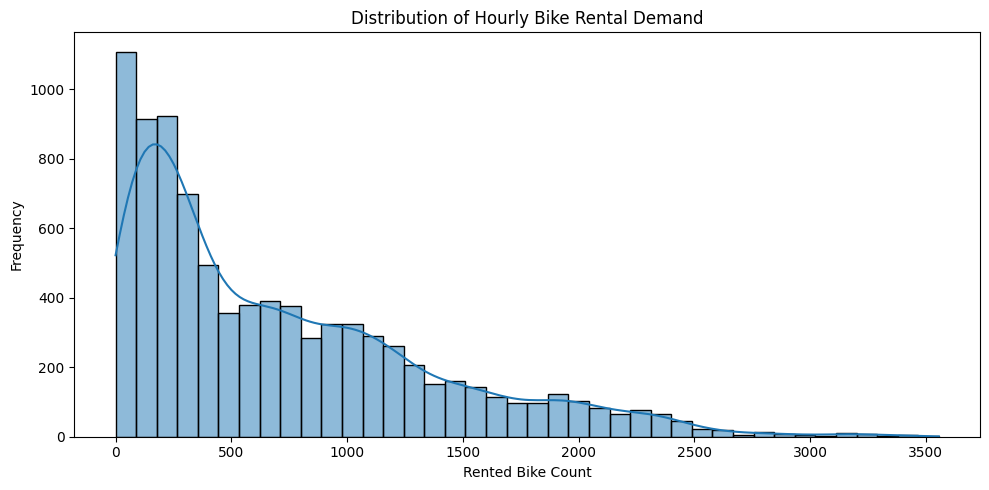

Skewness of Rented Bike Count: 1.153


In [57]:
# ============================================================
#  Distribution of Rented Bike Count
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_df,
    x="Rented_Bike_Count",
    bins=40,
    kde=True
)

plt.title("Distribution of Hourly Bike Rental Demand")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# numerical skewness
print(
    "Skewness of Rented Bike Count:",
    round(eda_df["Rented_Bike_Count"].skew(), 3)
)

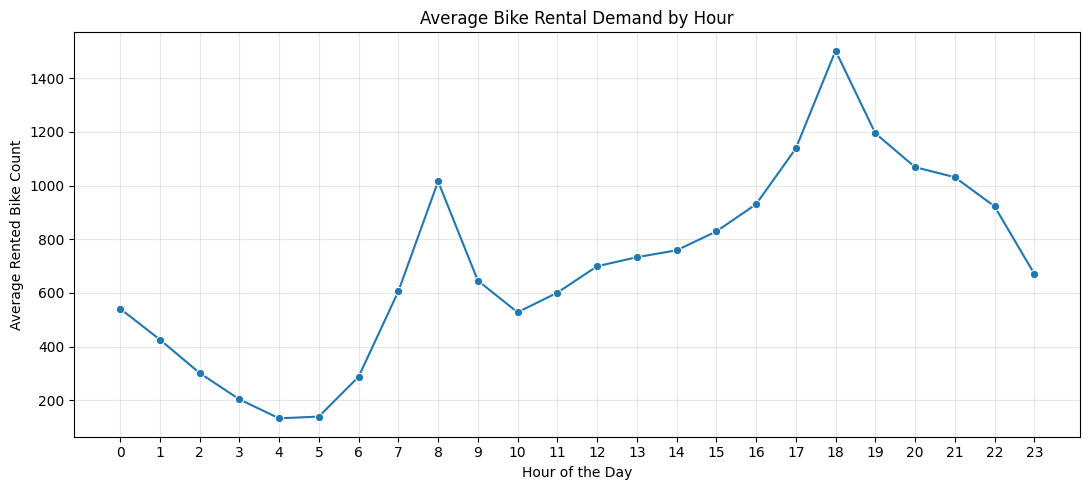

In [58]:
# ============================================================
#  Average Bike Demand by Hour
# ============================================================

hourly_demand = (
    eda_df
    .groupby("Hour")["Rented_Bike_Count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=hourly_demand,
    x="Hour",
    y="Rented_Bike_Count",
    marker="o"
)

plt.title("Average Bike Rental Demand by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Rented Bike Count")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

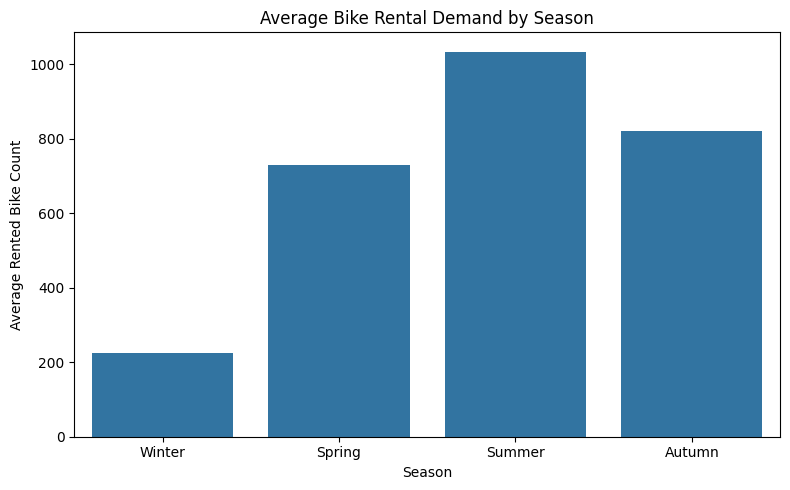

  Seasons  Rented_Bike_Count
0  Winter         225.541204
1  Spring         730.031250
2  Summer        1034.073370
3  Autumn         819.597985


In [59]:
# ============================================================
#  Average Bike Demand by Season
# ============================================================

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

seasonal_demand = (
    eda_df
    .groupby("Seasons")["Rented_Bike_Count"]
    .mean()
    .reindex(season_order)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=seasonal_demand,
    x="Seasons",
    y="Rented_Bike_Count"
)

plt.title("Average Bike Rental Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Rented Bike Count")
plt.tight_layout()
plt.show()

print(seasonal_demand)

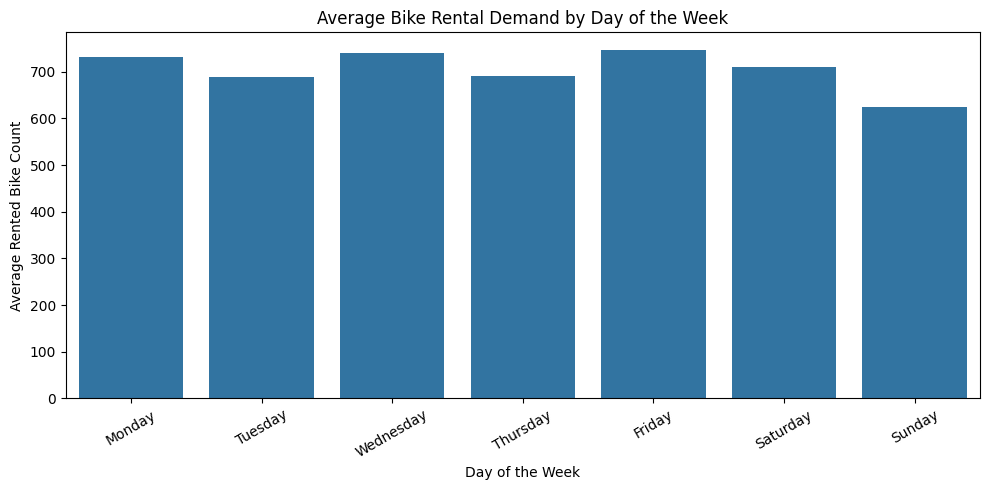

  Weekday_Name  Rented_Bike_Count
0       Monday         730.563301
1      Tuesday         687.977564
2    Wednesday         740.349359
3     Thursday         690.704327
4       Friday         747.117925
5     Saturday         709.528846
6       Sunday         625.155449


In [60]:
# ============================================================
# Average Bike Demand by Day of the Week
# ============================================================

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = (
    eda_df
    .groupby("Weekday_Name")["Rented_Bike_Count"]
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_demand,
    x="Weekday_Name",
    y="Rented_Bike_Count"
)

plt.title("Average Bike Rental Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Rented Bike Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(weekday_demand)

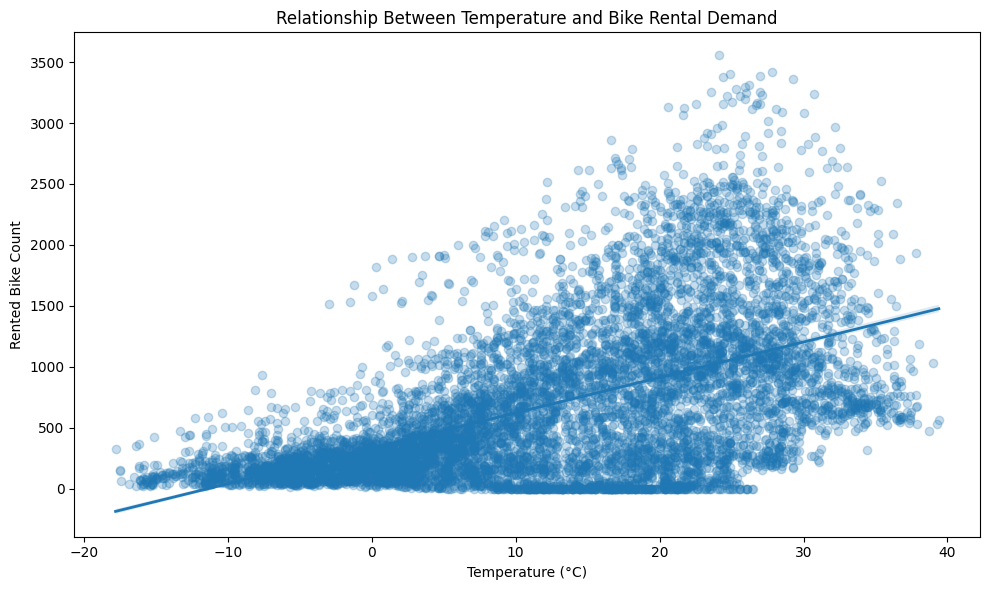

Correlation between Temperature and Bike Demand: 0.539


In [61]:
# ============================================================
#  Relationship Between Temperature and Demand
# ============================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=eda_df,
    x="Temperature°C",
    y="Rented_Bike_Count",
    scatter_kws={"alpha": 0.25},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Temperature and Bike Rental Demand")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rented Bike Count")
plt.tight_layout()
plt.show()

temperature_correlation = eda_df[
    ["Temperature°C", "Rented_Bike_Count"]
].corr().iloc[0, 1]

print(
    "Correlation between Temperature and Bike Demand:",
    round(temperature_correlation, 3)
)

In [62]:
# ============================================================
#   Rainfall Categories
# ============================================================

eda_df["Rainfall_Category"] = pd.cut(
    eda_df["Rainfallmm"],
    bins=[-0.01, 0, 5, 15, float("inf")],
    labels=[
        "No Rain",
        "Light Rain",
        "Moderate Rain",
        "Heavy Rain"
    ]
)

print(eda_df["Rainfall_Category"].value_counts())

Rainfall_Category
No Rain          8232
Light Rain        462
Moderate Rain      53
Heavy Rain         13
Name: count, dtype: int64


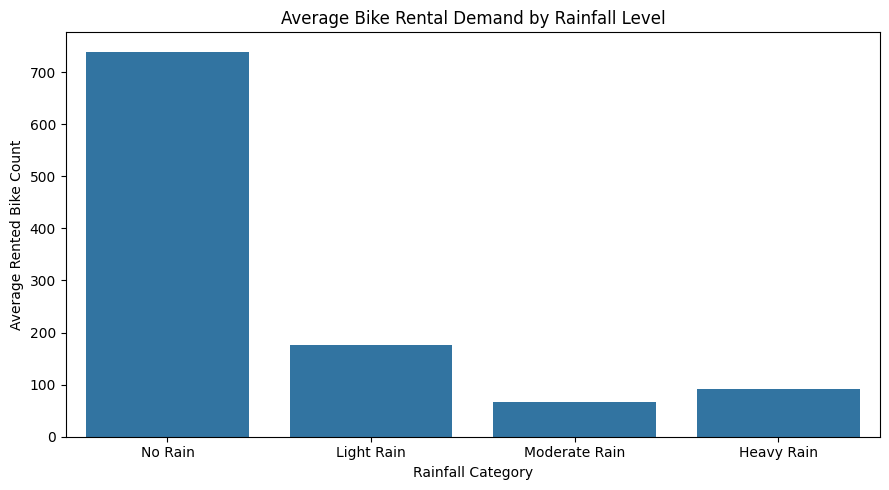

  Rainfall_Category  Rented_Bike_Count
0           No Rain         739.311103
1        Light Rain         176.655844
2     Moderate Rain          66.207547
3        Heavy Rain          90.846154


In [63]:
# ============================================================
#    Average Demand by Rainfall Category
# ============================================================

rainfall_order = [
    "No Rain",
    "Light Rain",
    "Moderate Rain",
    "Heavy Rain"
]

rainfall_demand = (
    eda_df
    .groupby(
        "Rainfall_Category",
        observed=False
    )["Rented_Bike_Count"]
    .mean()
    .reindex(rainfall_order)
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=rainfall_demand,
    x="Rainfall_Category",
    y="Rented_Bike_Count"
)

plt.title("Average Bike Rental Demand by Rainfall Level")
plt.xlabel("Rainfall Category")
plt.ylabel("Average Rented Bike Count")
plt.tight_layout()
plt.show()

print(rainfall_demand)

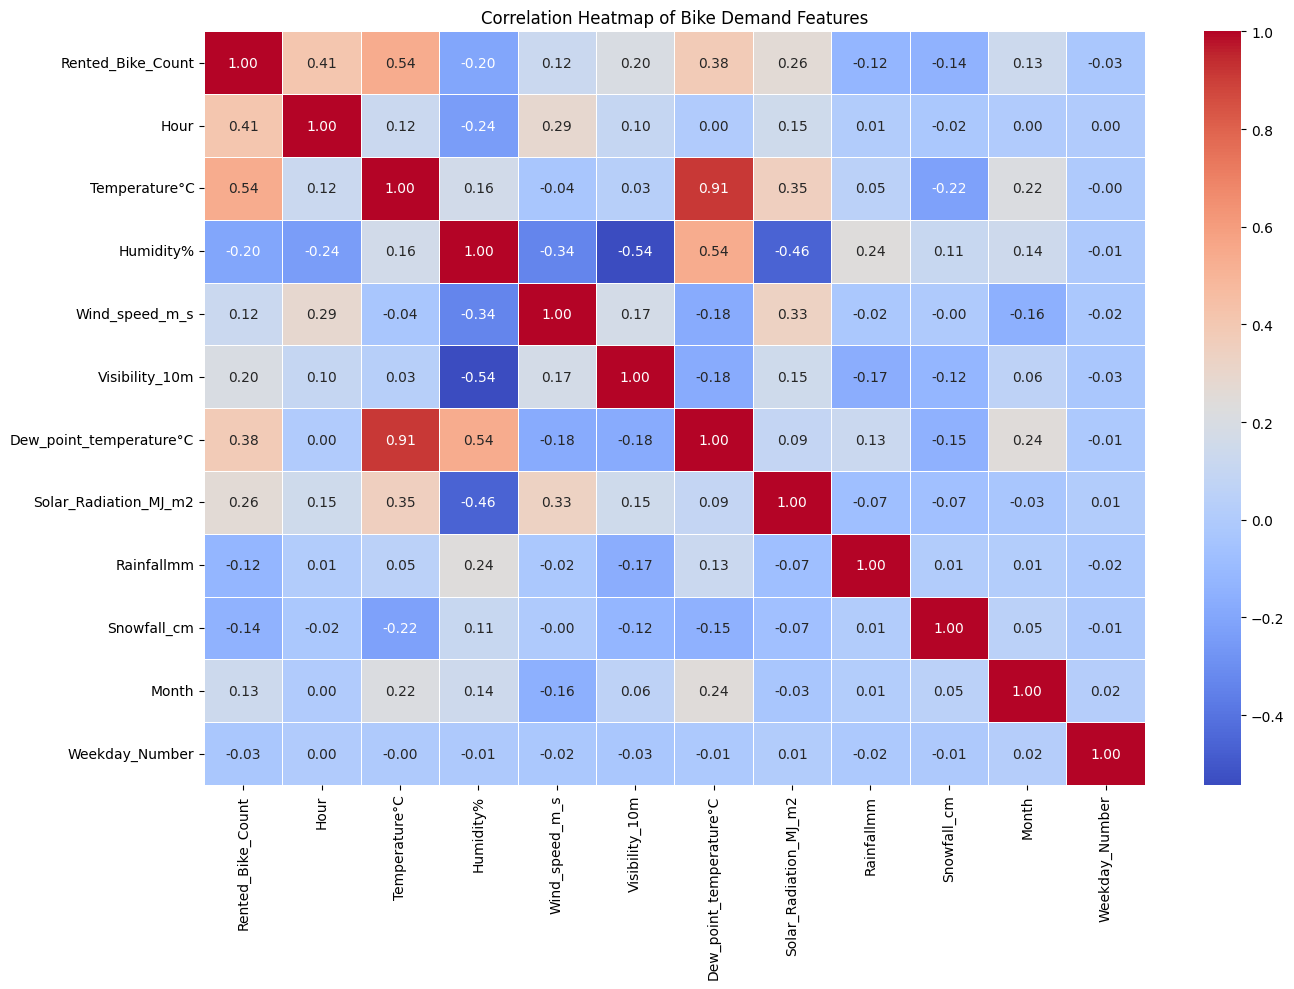

In [64]:
# ============================================================
#   Correlation Heatmap
# ============================================================

# Selecting numerical columns
numerical_columns = [
    "Rented_Bike_Count",
    "Hour",
    "Temperature°C",
    "Humidity%",
    "Wind_speed_m_s",
    "Visibility_10m",
    "Dew_point_temperature°C",
    "Solar_Radiation_MJ_m2",
    "Rainfallmm",
    "Snowfall_cm",
    "Month",
    "Weekday_Number"
]

#correlation matrix
correlation_matrix = eda_df[numerical_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Bike Demand Features")
plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# Ranking Features by Correlation with Target
# ============================================================

feature_correlations = (
    correlation_matrix["Rented_Bike_Count"]
    .drop("Rented_Bike_Count")
    .sort_values(ascending=False)
)

print("Numerical features ranked by correlation with bike demand:")
print(feature_correlations)

Numerical features ranked by correlation with bike demand:
Temperature°C              0.538558
Hour                       0.410257
Dew_point_temperature°C    0.379788
Solar_Radiation_MJ_m2      0.261837
Visibility_10m             0.199280
Month                      0.133514
Wind_speed_m_s             0.121108
Weekday_Number            -0.029357
Rainfallmm                -0.123074
Snowfall_cm               -0.141804
Humidity%                 -0.199780
Name: Rented_Bike_Count, dtype: float64


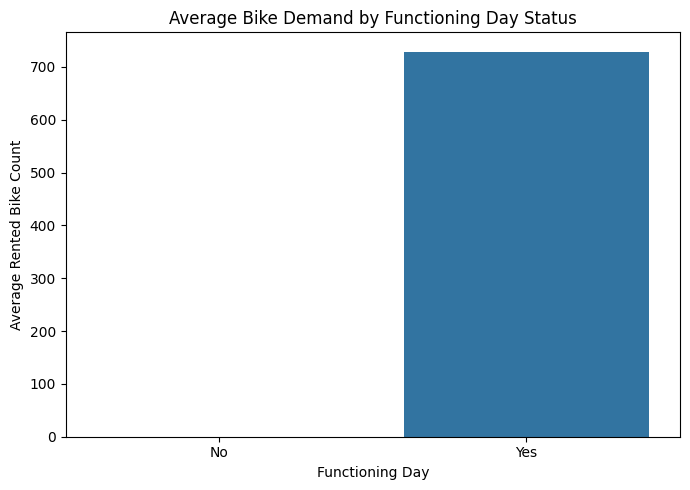

  Functioning_Day  Rented_Bike_Count
0              No           0.000000
1             Yes         729.156999


In [66]:
# ============================================================
#  Demand by Functioning Day
# ============================================================

functioning_demand = (
    eda_df
    .groupby("Functioning_Day")["Rented_Bike_Count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=functioning_demand,
    x="Functioning_Day",
    y="Rented_Bike_Count"
)

plt.title("Average Bike Demand by Functioning Day Status")
plt.xlabel("Functioning Day")
plt.ylabel("Average Rented Bike Count")
plt.tight_layout()
plt.show()

print(functioning_demand)